C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\1313395758.py:75: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\1313395758.py:75: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\1313395758.py:75: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\1313395758.py:75: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\1313395758.py:75: UserWarning: Glyph 36215 (\N{CJK UNIFIED IDEOGRAPH-8D77}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\1313395758.py:75: UserWarni

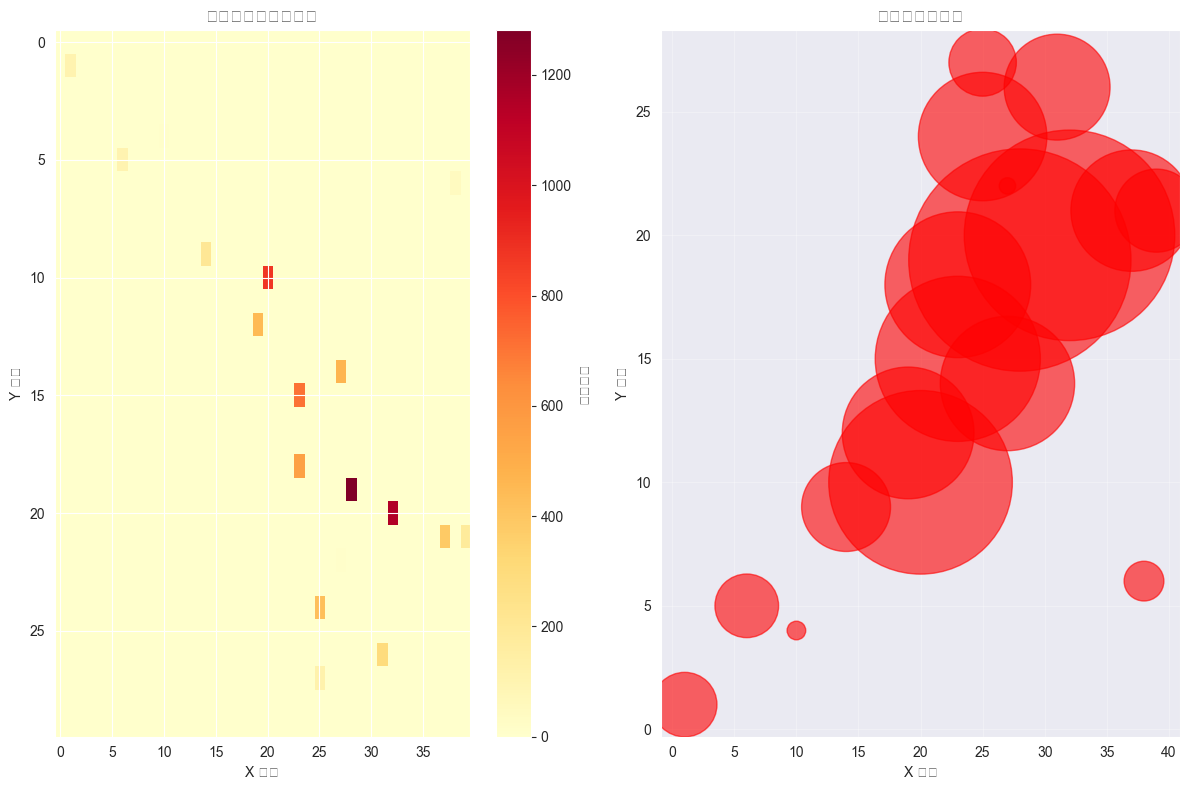

总轨迹数: 7353
唯一起点数: 18
最频繁的起点: [(788, 1281), (832, 1149), (420, 874), (623, 707), (743, 551)]


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def visualize_trajectory_starts(csv_path, width=40, height=30):
    """
    可视化轨迹起点分布

    参数:
    csv_path: trajs_sliced_0919_40x30.csv 文件路径
    width: 网格宽度 (默认40)
    height: 网格高度 (默认30)
    """
    # 读取数据
    df = pd.read_csv(csv_path)

    # 解析轨迹数据
    starts = []
    for idx, row in df.iterrows():
        if row['trajs'] != '[]' and pd.notna(row['trajs']):
            try:
                trajs = eval(row['trajs'])  # 解析轨迹字符串
                if len(trajs) > 0:
                    start_state = trajs[0][0]  # 第一个状态
                    starts.append(start_state)
            except:
                continue

    if not starts:
        print("没有找到有效的轨迹数据")
        return

    # 统计起点频率
    start_counts = Counter(starts)

    # 创建网格
    grid = np.zeros((height, width))

    # 将状态ID转换为坐标并填充网格
    for state_id, count in start_counts.items():
        x = state_id % width
        y = state_id // width
        if 0 <= x < width and 0 <= y < height:
            grid[y, x] = count

    # 可视化
    plt.figure(figsize=(12, 8))

    # 热力图
    plt.subplot(1, 2, 1)
    im = plt.imshow(grid, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, label='起点频次')
    plt.title('轨迹起点分布热力图')
    plt.xlabel('X 坐标')
    plt.ylabel('Y 坐标')

    # 散点图
    plt.subplot(1, 2, 2)
    x_coords = [state % width for state in starts]
    y_coords = [state // width for state in starts]

    # 创建散点图，点的大小表示频次
    scatter_counts = Counter(zip(x_coords, y_coords))
    x_scatter = [coord[0] for coord in scatter_counts.keys()]
    y_scatter = [coord[1] for coord in scatter_counts.keys()]
    sizes = [count * 20 for count in scatter_counts.values()]  # 放大点的大小

    plt.scatter(x_scatter, y_scatter, s=sizes, alpha=0.6, c='red')
    plt.title('轨迹起点散点图')
    plt.xlabel('X 坐标')
    plt.ylabel('Y 坐标')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 打印统计信息
    print(f"总轨迹数: {len(starts)}")
    print(f"唯一起点数: {len(start_counts)}")
    print(f"最频繁的起点: {start_counts.most_common(5)}")

    return grid, start_counts

# 使用示例
csv_path = 'wifi_track_data/dacang/track_data/trajs_0919_40x30.csv'
grid, start_counts = visualize_trajectory_starts(csv_path)

In [12]:
import pandas as pd

def count_unique_states_in_slices(csv_path):
    """
    统计切片轨迹中所有片段的唯一起点数

    参数:
    csv_path: dacang_track_data_sliced_cluster.csv 文件路径

    返回:
    unique_states: 所有唯一起点的集合
    total_unique_count: 唯一起点总数
    """
    # 读取数据
    df = pd.read_csv(csv_path)

    # 收集所有探针ID（a列）作为状态
    all_states = set(df['a'].dropna().unique())

    # 统计结果
    total_unique_count = len(all_states)
    unique_states = sorted(list(all_states))

    print(f"唯一起点总数: {total_unique_count}")
    print(f"状态范围: {min(unique_states)} - {max(unique_states)}")

    return unique_states, total_unique_count

# 使用示例
csv_path = 'wifi_track_data/dacang/track_data/dacang_track_data_sliced_cluster.csv'
unique_states, count = count_unique_states_in_slices(csv_path)

唯一起点总数: 167
状态范围: 4 - 99887


坐标范围: X(13.9, 399.3), Y(16.4, 270.2)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\21571221.py:102: UserWarning: Glyph 22352 (\N{CJK UNIFIED IDEOGRAPH-5750}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\21571221.py:102: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\21571221.py:102: UserWarning: Glyph 25152 (\N{CJK UNIFIED IDEOGRAPH-6240}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\21571221.py:102: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\21571221.py:102: UserWarning: Glyph 25506 (\N{CJK UNIFIED IDEOGRAPH-63A2}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_30892\21571221.py:102: UserWarning: Gl

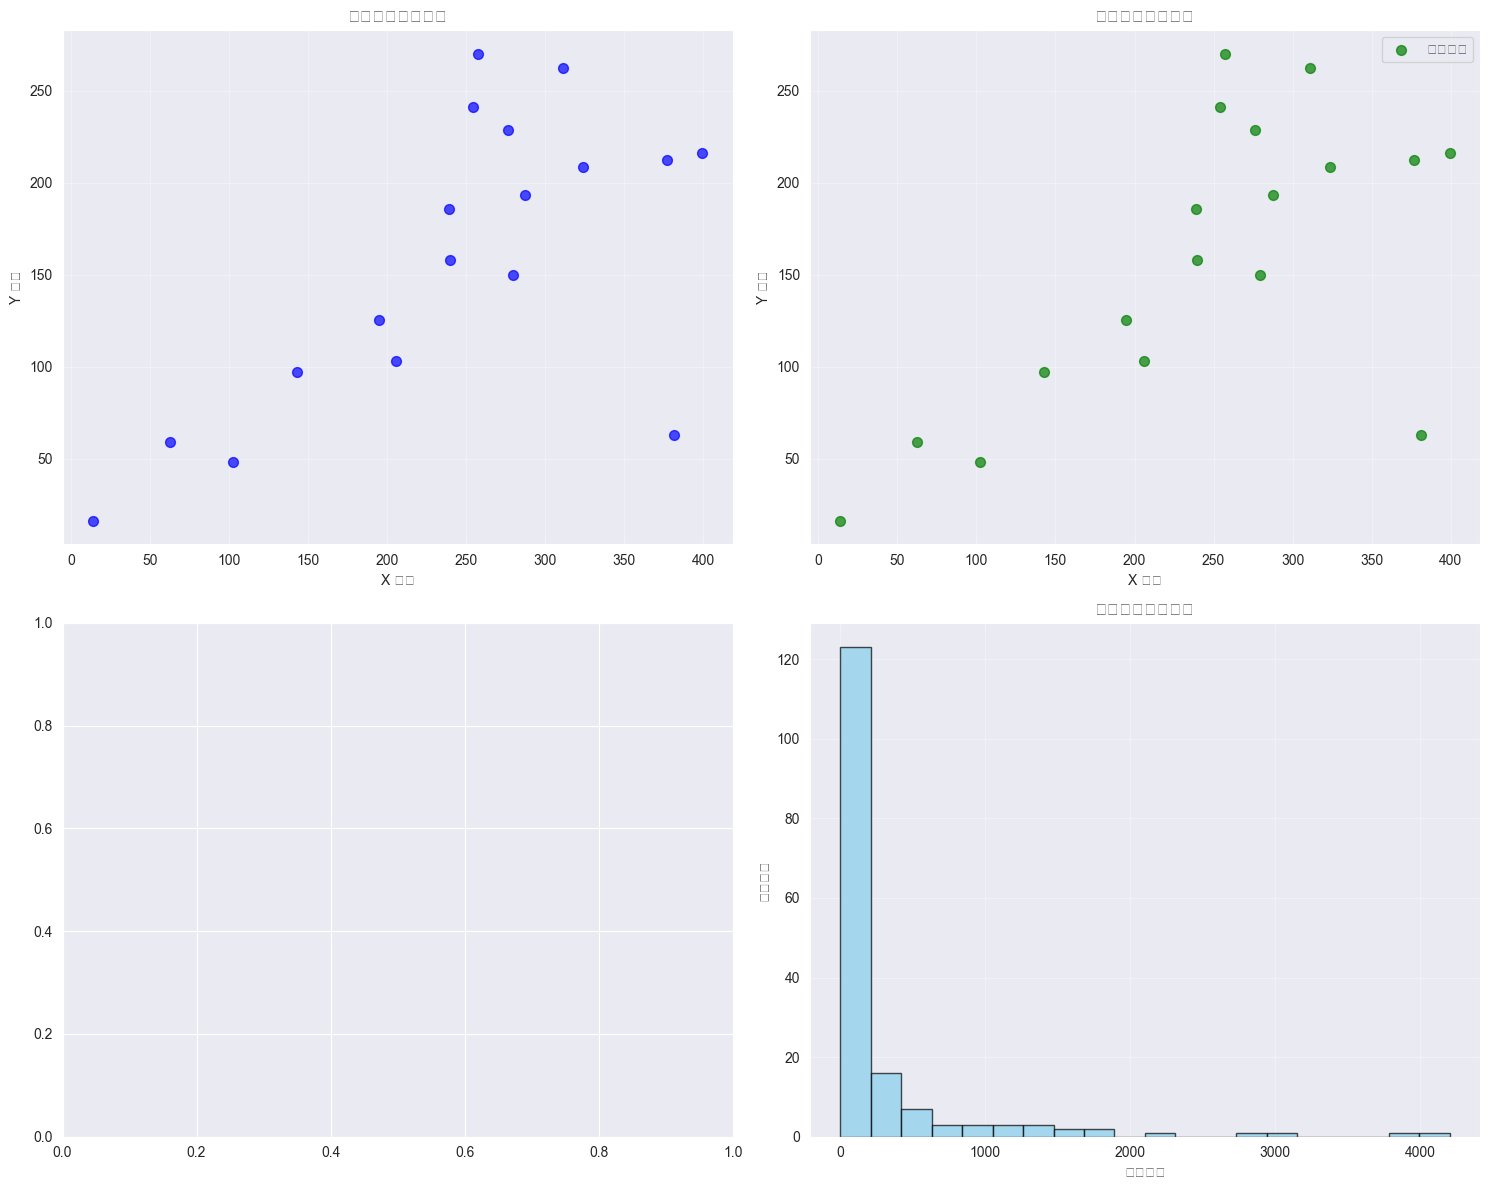

唯一起点总数: 167
真实探针数量: 18
虚拟探针数量: 0
未知探针数量: 149
状态范围: 4 - 99887
最频繁的5个起点: [(5, 4201), (95, 3903), (99, 2949), (22, 2770), (32, 2303)]

前10个探针的详细信息:
  1. ID:5 (real) - 坐标:(287.4, 193.2) - 频次:4201
  2. ID:95 (real) - 坐标:(323.6, 208.7) - 频次:3903
  3. ID:99 (real) - 坐标:(239.8, 158.2) - 频次:2949
  4. ID:22 (real) - 坐标:(205.9, 103.5) - 频次:2770
  5. ID:32 (real) - 坐标:(239.1, 185.9) - 频次:2303
  6. ID:120 (real) - 坐标:(279.5, 149.8) - 频次:1861
  7. ID:85119 (未知) - 频次:1814
  8. ID:33 (real) - 坐标:(194.9, 125.4) - 频次:1596
  9. ID:84 (real) - 坐标:(254.1, 241.3) - 频次:1590
  10. ID:32684 (未知) - 频次:1411


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def visualize_unique_states_with_positions(csv_path, pos_path='wifi_track_data/dacang/pos_data/wifi_pos.csv'):
    """
    使用wifi_pos.csv中的位置信息和ID标签可视化唯一起点分布

    参数:
    csv_path: dacang_track_data_sliced_cluster.csv 文件路径
    pos_path: wifi_pos.csv 文件路径
    """
    # 读取数据
    df = pd.read_csv(csv_path)
    wifi_pos = pd.read_csv(pos_path)

    # 收集所有探针ID
    all_states = set(df['a'].dropna().unique())
    state_counts = Counter(df['a'].dropna())

    # 创建探针ID到坐标和类型的映射
    probe_info = {}
    for _, row in wifi_pos.iterrows():
        probe_info[row['wifi']] = {
            'x': row['X'],
            'y': row['Y'],
            'id_type': row['ID'],
            'parents': row['parents'],
            'restored_x': row['restored_x'],
            'restored_y': row['restored_y']
        }

    # 分离真实探针和虚拟探针（除了real以外都是virtual）
    real_probes = []
    virtual_probes = []
    unknown_probes = []

    for state in all_states:
        if state in probe_info:
            if probe_info[state]['id_type'] == 'real':
                real_probes.append(state)
            else:  # 除了real以外的所有探针都算作virtual
                virtual_probes.append(state)
        else:
            unknown_probes.append(state)

    # 获取坐标范围
    all_x = [probe_info[s]['x'] for s in all_states if s in probe_info]
    all_y = [probe_info[s]['y'] for s in all_states if s in probe_info]

    if not all_x:
        print("没有找到匹配的探针位置信息")
        return

    x_min, x_max = min(all_x), max(all_x)
    y_min, y_max = min(all_y), max(all_y)

    print(f"坐标范围: X({x_min:.1f}, {x_max:.1f}), Y({y_min:.1f}, {y_max:.1f})")

    # 创建可视化
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. 所有探针分布
    all_x_coords = [probe_info[s]['x'] for s in all_states if s in probe_info]
    all_y_coords = [probe_info[s]['y'] for s in all_states if s in probe_info]
    axes[0,0].scatter(all_x_coords, all_y_coords, c='blue', alpha=0.7, s=50)
    axes[0,0].set_title('所有探针位置分布')
    axes[0,0].set_xlabel('X 坐标')
    axes[0,0].set_ylabel('Y 坐标')
    axes[0,0].grid(True, alpha=0.3)

    # 2. 真实探针分布
    real_x = [probe_info[s]['x'] for s in real_probes if s in probe_info]
    real_y = [probe_info[s]['y'] for s in real_probes if s in probe_info]
    if real_x:
        axes[0,1].scatter(real_x, real_y, c='green', alpha=0.7, s=50, label='真实探针')
        axes[0,1].set_title('真实探针位置分布')
        axes[0,1].set_xlabel('X 坐标')
        axes[0,1].set_ylabel('Y 坐标')
        axes[0,1].grid(True, alpha=0.3)
        axes[0,1].legend()

    # 3. 虚拟探针分布
    virtual_x = [probe_info[s]['x'] for s in virtual_probes if s in probe_info]
    virtual_y = [probe_info[s]['y'] for s in virtual_probes if s in probe_info]
    if virtual_x:
        axes[1,0].scatter(virtual_x, virtual_y, c='red', alpha=0.7, s=50, label='虚拟探针')
        axes[1,0].set_title('虚拟探针位置分布')
        axes[1,0].set_xlabel('X 坐标')
        axes[1,0].set_ylabel('Y 坐标')
        axes[1,0].grid(True, alpha=0.3)
        axes[1,0].legend()

    # 4. 频次分布
    axes[1,1].hist(list(state_counts.values()), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[1,1].set_title('探针出现频次分布')
    axes[1,1].set_xlabel('出现频次')
    axes[1,1].set_ylabel('探针数量')
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 打印统计信息
    print(f"唯一起点总数: {len(all_states)}")
    print(f"真实探针数量: {len(real_probes)}")
    print(f"虚拟探针数量: {len(virtual_probes)}")
    print(f"未知探针数量: {len(unknown_probes)}")
    print(f"状态范围: {min(all_states)} - {max(all_states)}")
    print(f"最频繁的5个起点: {state_counts.most_common(5)}")

    # 显示一些具体的探针信息
    print("\n前10个探针的详细信息:")
    for i, (state, count) in enumerate(state_counts.most_common(10)):
        if state in probe_info:
            info = probe_info[state]
            print(f"  {i+1}. ID:{state} ({info['id_type']}) - 坐标:({info['x']:.1f}, {info['y']:.1f}) - 频次:{count}")
            if info['id_type'] != 'real' and info['parents'] != 'N':
                print(f"      父探针: {info['parents']}")
        else:
            print(f"  {i+1}. ID:{state} (未知) - 频次:{count}")

    return all_states, state_counts, probe_info

# 使用示例
csv_path = 'wifi_track_data/dacang/track_data/dacang_track_data_sliced_cluster.csv'
pos_path = 'wifi_track_data/dacang/pos_data/wifi_pos.csv'
unique_states, counts, coords = visualize_unique_states_with_positions(csv_path, pos_path)

In [26]:
import pandas as pd

def compare_probe_ids(csv_path, pos_path='wifi_track_data/dacang/pos_data/wifi_pos.csv'):
    """
    比较两个文件中的探针ID匹配情况

    参数:
    csv_path: dacang_track_data_sliced_cluster.csv 文件路径
    pos_path: wifi_pos.csv 文件路径
    """
    # 读取数据
    df = pd.read_csv(csv_path)
    wifi_pos = pd.read_csv(pos_path)

    # 获取探针ID集合
    traj_probes = set(df['a'].dropna().unique())
    pos_probes = set(wifi_pos['wifi'].unique())

    # 计算匹配情况
    matched = traj_probes.intersection(pos_probes)
    traj_only = traj_probes - pos_probes
    pos_only = pos_probes - traj_probes

    print("=== 探针ID匹配情况 ===")
    print(f"轨迹数据中的探针数量: {len(traj_probes)}")
    print(f"位置数据中的探针数量: {len(pos_probes)}")
    print(f"匹配的探针数量: {len(matched)}")
    print(f"只在轨迹中的探针数量: {len(traj_only)}")
    print(f"只在位置数据中的探针数量: {len(pos_only)}")

    print(f"\n匹配率: {len(matched)/len(traj_probes)*100:.1f}%")

    # 显示一些不匹配的探针ID
    print(f"\n轨迹中有但位置数据中没有的探针ID (前10个):")
    print(list(traj_only)[:10])

    print(f"\n位置数据中有但轨迹中没有的探针ID (前10个):")
    print(list(pos_only)[:10])

    # 检查虚拟探针匹配情况
    virtual_in_pos = set(wifi_pos[wifi_pos['ID'] != 'real']['wifi'].unique())
    virtual_in_traj = traj_probes.intersection(virtual_in_pos)

    print(f"\n=== 虚拟探针匹配情况 ===")
    print(f"位置数据中的虚拟探针数量: {len(virtual_in_pos)}")
    print(f"轨迹中匹配的虚拟探针数量: {len(virtual_in_traj)}")
    print(f"虚拟探针匹配率: {len(virtual_in_traj)/len(virtual_in_pos)*100:.1f}%")

    return matched, traj_only, pos_only

# 使用示例
csv_path = 'wifi_track_data/dacang/track_data/dacang_track_data_sliced_cluster.csv'
pos_path = 'wifi_track_data/dacang/pos_data/wifi_pos.csv'
matched, traj_only, pos_only = compare_probe_ids(csv_path, pos_path)

=== 探针ID匹配情况 ===
轨迹数据中的探针数量: 167
位置数据中的探针数量: 163
匹配的探针数量: 18
只在轨迹中的探针数量: 149
只在位置数据中的探针数量: 145

匹配率: 10.8%

轨迹中有但位置数据中没有的探针ID (前10个):
[np.int64(93699), np.int64(62468), np.int64(44040), np.int64(18961), np.int64(53269), np.int64(66586), np.int64(26651), np.int64(84512), np.int64(89633), np.int64(15906)]

位置数据中有但轨迹中没有的探针ID (前10个):
[np.int64(79368), np.int64(29193), np.int64(60938), np.int64(98826), np.int64(34825), np.int64(40458), np.int64(61458), np.int64(80918), np.int64(69657), np.int64(21019)]

=== 虚拟探针匹配情况 ===
位置数据中的虚拟探针数量: 144
轨迹中匹配的虚拟探针数量: 0
虚拟探针匹配率: 0.0%
